In [172]:
#utils I made to look at this data
import switchy.util as ut
import scanpy as sc
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl

import seaborn as sns
import autoreload
from nheatmap import nhm, scripts
import sklearn.decomposition, sklearn.cluster
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "outs"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

data_dir = "../../../SharedData/"
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [173]:
# Load Data 
ab_tx, switch_tx = ut.loadSJoutIGH(data_dir + 'CombinedSJouts_chr14_IGH.fthr')

filtering SJout to just IGH locus
making SJTable human readable


In [177]:
changeodbH = pd.read_csv('../../../SharedData/ShazamQCedIGH.tab', index_col = 0, sep = '\t')

In [178]:
changeodbH['CELL'] = changeodbH.loc[:,'cell']

In [5]:
_df = ab_tx[~ab_tx.exon_simple.str.contains("IGHD")]

In [9]:
_x = _df.groupby('cell').max()

In [233]:
df = pd.read_feather('../../../SharedData/CombinedSJouts_chr14_IGH.fthr')

In [234]:
df = df[df.unique_mapping > 10]

In [235]:
df_exoncoordinates = pd.read_csv('/home/mswift/B_cells/CSR/sc_RNAseq/data_tables/metadata/IGHC_exon_coordinates.csv', header=None, names=['exon', 'coordinate'])

In [236]:
df_exoncoordinates['coordplusone'] = df_exoncoordinates.coordinate + 1 
df_exoncoordinates['coordplustwo'] = df_exoncoordinates.coordinate + 2 
df_exoncoordinates['coordminusone'] = df_exoncoordinates.coordinate - 1
df_exoncoordinates['coordminustwo'] = df_exoncoordinates.coordinate - 2

In [237]:
print(df[df.start.isin(df_exoncoordinates.coordinate)].shape)
print(df[df.start.isin(df_exoncoordinates.coordplusone)].shape)
print(df[df.start.isin(df_exoncoordinates.coordplustwo)].shape)

print(df[df.start.isin(df_exoncoordinates.coordminusone)].shape)
print(df[df.start.isin(df_exoncoordinates.coordminustwo)].shape)


(8010, 13)
(38176, 13)
(68, 13)
(72, 13)
(124, 13)


In [238]:
exon_coords = pd.concat([df_exoncoordinates.coordinate, df_exoncoordinates.coordplusone])

In [239]:
exon_coords.unique().shape

(1156,)

In [240]:
df_features = df.groupby(['start', 'end']).count()

In [245]:
df_features

,,level_0,index,chrom,strand,intron_motif,annotated,unique_mapping,multi_mapping,max_overhang,cell,SAMPLE
start,end,,,,,,,,,,,
105286377,105864214,1,1,1,1,1,1,1,1,1,1,1
105337777,105644527,1,1,1,1,1,1,1,1,1,1,1
105339294,105587756,1,1,1,1,1,1,1,1,1,1,1
105352059,105587652,1,1,1,1,1,1,1,1,1,1,1
105355357,105644067,3,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...
106851418,106851500,115,115,115,115,115,115,115,115,115,115,115
106854326,106855797,1,1,1,1,1,1,1,1,1,1,1
106872571,106872970,1,1,1,1,1,1,1,1,1,1,1


In [241]:
df_selected_features = df_features[df_features.cell > 10]

In [242]:
df_selected_features.reset_index(inplace = True)

In [246]:
df_selected_features

,start,end,level_0,index,chrom,strand,intron_motif,annotated,unique_mapping,multi_mapping,max_overhang,cell,SAMPLE,splice_feature
0,105450297,105707146,15,15,15,15,15,15,15,15,15,15,15,211157443
1,105551215,105707229,51,51,51,51,51,51,51,51,51,51,51,211258444
2,105583854,105584132,262,262,262,262,262,262,262,262,262,262,262,211167986
3,105584351,105586998,30,30,30,30,30,30,30,30,30,30,30,211171349
4,105586918,105588232,37,37,37,37,37,37,37,37,37,37,37,211175150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,106775376,106790910,15,15,15,15,15,15,15,15,15,15,15,213566286
550,106791005,106791107,12,12,12,12,12,12,12,12,12,12,12,213582112
551,106803005,106803107,26,26,26,26,26,26,26,26,26,26,26,213606112
552,106810747,106810849,61,61,61,61,61,61,61,61,61,61,61,213621596


In [247]:
df_selected_features['splice_feature'] = df_selected_features['start'] + df_selected_features['end']

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [248]:
df['splice_feature'] = df['start'] + df['end']

In [249]:
df_feature_selected = df[df['splice_feature'].isin(df_selected_features.splice_feature)]

In [250]:
_df = df_feature_selected[['splice_feature', 'cell', 'unique_mapping']]

In [254]:
_df = _df.drop_duplicates(subset=['splice_feature', 'cell'])

In [142]:
df.pivot(index = 'countries', columns='metrics', values = 'values')

metrics,gdp_percapita,population_in_million
countries,,
A,2000,100
B,7000,200
C,15000,120


In [147]:
_df.melt()

,splice_feature,cell,unique_mapping
3,211321837,PASL_2_PA_11_plate_1_D11,1027
4,211322087,PASL_2_PA_11_plate_1_D11,15
7,211200878,PASL_2_PA_11_plate_1_D11,218
8,211201695,PASL_2_PA_11_plate_1_D11,1154
9,211202630,PASL_2_PA_11_plate_1_D11,1681
...,...,...,...
239254,212921256,B107914_A20,32
239267,212537928,B107914_A20,7834
239269,212553790,B107914_A20,6132
239284,212874252,B107914_A20,62


In [259]:
GenebyCell = _df.pivot(index = 'splice_feature', columns='cell', values='unique_mapping')

In [260]:
CellbyGene = GenebyCell.T

In [263]:
CellbyGene.fillna(0, inplace=True)

In [265]:
CellbyGene.columns

Int64Index([211157443, 211167986, 211171349, 211174559, 211174688, 211174885, 211175150, 211175599, 211175963, 211178330,
            ...
            213500044, 213512910, 213519283, 213524883, 213541863, 213566286, 213582112, 213606112, 213621596, 213702918], dtype='int64', name='splice_feature', length=553)

In [271]:
cols = CellbyGene.columns.to_list()
index = CellbyGene.index.to_list()
data = CellbyGene.values
NewCellbyGene = pd.DataFrame(data = CellbyGene.values, columns=cols, index=index)

In [275]:
NewCellbyGene.to_csv('../data/SpliceCountbyFeature.csv')

In [150]:
_df.reset_index(inplace=True)`

In [151]:
_df.pivot(index = _df['cell'], columns = _df['splice_feature'], values = _df['unique_mapping'])

KeyError: "None of [Index(['PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11', 'PASL_2_PA_11_plate_1_D11',\n       ...\n       'B107914_A20', 'B107914_A20', 'B107914_A20', 'B107914_A20', 'B107914_A20', 'B107914_A20', 'B107914_A20', 'B107914_A20', 'B107914_A20', 'B107914_A20'], dtype='object', length=63291)] are in the [columns]"

In [162]:
_x = pd.DataFrame(data = [['A', 'B', 'C', 'A', 'B', 'C'], [1,12,10, 12,12,10], ['cell1', 'cell1', 'cell2', 'cell3', 'cell4', 'cell5', 'cell6']])

In [164]:
_x = _x.T

In [166]:
_x.columns = ['feature', 'counts', 'cell']

In [171]:
_df.groupby('cell').count()

,index,splice_feature,unique_mapping
cell,,,
AgSeqPooled_A11,11,11,11
AgSeqPooled_A12,15,15,15
AgSeqPooled_A4,2,2,2
AgSeqPooled_A5,7,7,7
AgSeqPooled_A7,14,14,14
...,...,...,...
PASL_5_PA_15_plate_2mod_H5,7,7,7
PASL_5_PA_15_plate_2mod_H6,36,36,36
PASL_5_PA_15_plate_2mod_H7,28,28,28


In [169]:
_df.iloc[]

,index,splice_feature,cell,unique_mapping
0,3,211321837,PASL_2_PA_11_plate_1_D11,1027
1,4,211322087,PASL_2_PA_11_plate_1_D11,15
2,7,211200878,PASL_2_PA_11_plate_1_D11,218
3,8,211201695,PASL_2_PA_11_plate_1_D11,1154
4,9,211202630,PASL_2_PA_11_plate_1_D11,1681
...,...,...,...,...
63286,239254,212921256,B107914_A20,32
63287,239267,212537928,B107914_A20,7834
63288,239269,212553790,B107914_A20,6132
63289,239284,212874252,B107914_A20,62


In [167]:
_x.pivot(index = 'cell', columns='feature', values = 'counts')

feature,A,B,C
cell,,,
cell1,1,NaN,NaN
cell2,NaN,12,NaN
cell3,NaN,NaN,10
cell4,12,NaN,NaN
cell5,NaN,12,NaN
cell6,NaN,NaN,10


In [55]:
ListOfDicts = []
for column in df_exoncoordinates.columns[1:]:
    Dict = dict(zip(df_exoncoordinates[column], df_exoncoordinates.exon))
    ListOfDicts.append(Dict)

In [56]:
df_Ab = df

In [57]:
_J_genes_start_dict = {105865406: "IGHJ1", 105863197: "IGHJ6", 105864586: 'IGHJ3', 105865198: 'IGHJ2', 105864214: 'IGHJ4', 105863813: 'IGHJ5'}

In [58]:
df_Ab['J_exon'] = df_Ab['end'].map(_J_genes_start_dict).fillna(df_Ab.end)

In [59]:
for i,mapping in enumerate(ListOfDicts):
    col = 'C_exon_' + str(i)
    df_Ab[col] = df_Ab['start'].map(mapping).fillna(0)

In [60]:
df = df_Ab

In [61]:
df_Ab = df_Ab[df_Ab.end.isin(_J_genes_start_dict.keys())]

In [81]:
df_Switch = df[df.end < 105863000]

In [84]:
df_Switch.C_exon_0.value_counts()

0                     81148
IGHM_exon1_5prime       867
IGHGP_exon4_3prime      719
IGHE_exon1_5prime       654
IGHG2_exon1_5prime      564
IGHG1_exon1_5prime      339
IGHA1_exon1_5prime      278
IGHG3_exon5_3prime      242
IGHG4_exon1_5prime      214
IGHG3_exon4_3prime      160
IGHD_exon1_5prime       113
IGHA2_exon1_5prime       87
IGHG3_exon3_3prime       86
IGHG2_exon3_3prime        7
IGHA2_exon1_3prime        6
IGHG1_exon3_3prime        4
IGHGP_exon3_3prime        2
IGHG1_exon2_3prime        1
IGHG4_exon3_3prime        1
Name: C_exon_0, dtype: int64

In [85]:
df_Switch.C_exon_1.value_counts()

0                      41974
IGHM_exon3_5prime       2271
IGHM_exon4_5prime       2258
IGHM_exon2_5prime       2202
IGHM_exon6_5prime       2164
IGHM_exon5_5prime       2154
IGHG3_exon6_5prime      1969
IGHG3_exon1_5prime      1591
IGHG3_exon7_5prime      1408
IGHG3_exon4_5prime      1378
IGHD_exon2_5prime       1322
IGHG2_exon4_5prime      1283
IGHG1_exon2_5prime      1280
IGHD_exon3_5prime       1279
IGHD_exon4_5prime       1221
IGHD_exon5_5prime       1168
IGHG3_exon5_5prime      1144
IGHG3_exon2_5prime      1107
IGHG1_exon4_5prime      1102
IGHD_exon7_5prime       1066
IGHG3_exon3_5prime      1033
IGHD_exon6_5prime        997
IGHG1_exon3_5prime       939
IGHD_exon6s_5prime       818
IGHG2_exon2_5prime       764
IGHG2_exon3_5prime       723
IGHG3_exon9_5prime       694
IGHA1_exon3_5prime       667
IGHA1_exon2_5prime       629
IGHE_exon4_5prime        569
IGHE_exon3_5prime        560
IGHG3_exon8_5prime       557
IGHE_exon2_5prime        546
IGHG4_exon4_5prime       484
IGHA2_exon3_5p

In [64]:
df_Ab.groupby('cell').unique_mapping.max()

cell
AgSeqPooled_A11               148
AgSeqPooled_A12               251
AgSeqPooled_A7                 39
AgSeqPooled_A9                298
AgSeqPooled_B10               571
                             ... 
PASL_5_PA_15_plate_2mod_H2    248
PASL_5_PA_15_plate_2mod_H5     62
PASL_5_PA_15_plate_2mod_H6     49
PASL_5_PA_15_plate_2mod_H7    212
PASL_5_PA_15_plate_2mod_H8     62
Name: unique_mapping, Length: 2829, dtype: int64

In [66]:
df_Ab.C_exon_0.value_counts()

IGHM_exon1_5prime     3019
IGHD_exon1_5prime     1368
IGHG1_exon1_5prime     728
IGHA1_exon1_5prime     703
0                      672
IGHG2_exon1_5prime     280
IGHA2_exon1_5prime     201
IGHE_exon1_5prime      148
IGHG4_exon1_5prime      38
IGHJ5_exon1_3prime      26
IGHJ6_exon1_3prime      21
IGHJ4_exon1_3prime       3
Name: C_exon_0, dtype: int64

In [75]:
df_Activated = df_Ab[~df_Ab.cell.str.contains("PASL")]

df_Activated = df_Activated[~df_Activated.cell.str.contains("Naive|IL68|B1079")]

In [77]:
df_Activated.C_exon_0.value_counts()

IGHM_exon1_5prime     1554
IGHD_exon1_5prime      471
0                      173
IGHG1_exon1_5prime     129
IGHG4_exon1_5prime      23
IGHA1_exon1_5prime      23
IGHG2_exon1_5prime      19
IGHE_exon1_5prime       10
IGHJ6_exon1_3prime       9
IGHJ5_exon1_3prime       5
IGHA2_exon1_5prime       4
Name: C_exon_0, dtype: int64

In [79]:
df_Activated[df_Activated.C_exon_0.str.contains('exon1_5prime')]

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [78]:
df_Activated.C_exon_1.value_counts()

0                     2267
IGHG3_exon1_5prime      95
IGHM_exon5_5prime       41
IGHM_exon3_5prime        4
IGHM_exon2_5prime        3
IGHM_exon4_5prime        2
IGHM_exon6_5prime        2
IGHG1_exon2_5prime       2
IGHG1_exon3_5prime       1
IGHG3_exon6_5prime       1
IGHG3_exon8_5prime       1
IGHG2_exon2_5prime       1
Name: C_exon_1, dtype: int64

In [224]:
df.drop_duplicates()

,countries,metrics,values
0,A,population_in_million,100
1,B,population_in_million,200
2,C,population_in_million,120
3,A,gdp_percapita,2000
4,B,gdp_percapita,7000
5,C,gdp_percapita,15000


ValueError: min() arg is an empty sequence

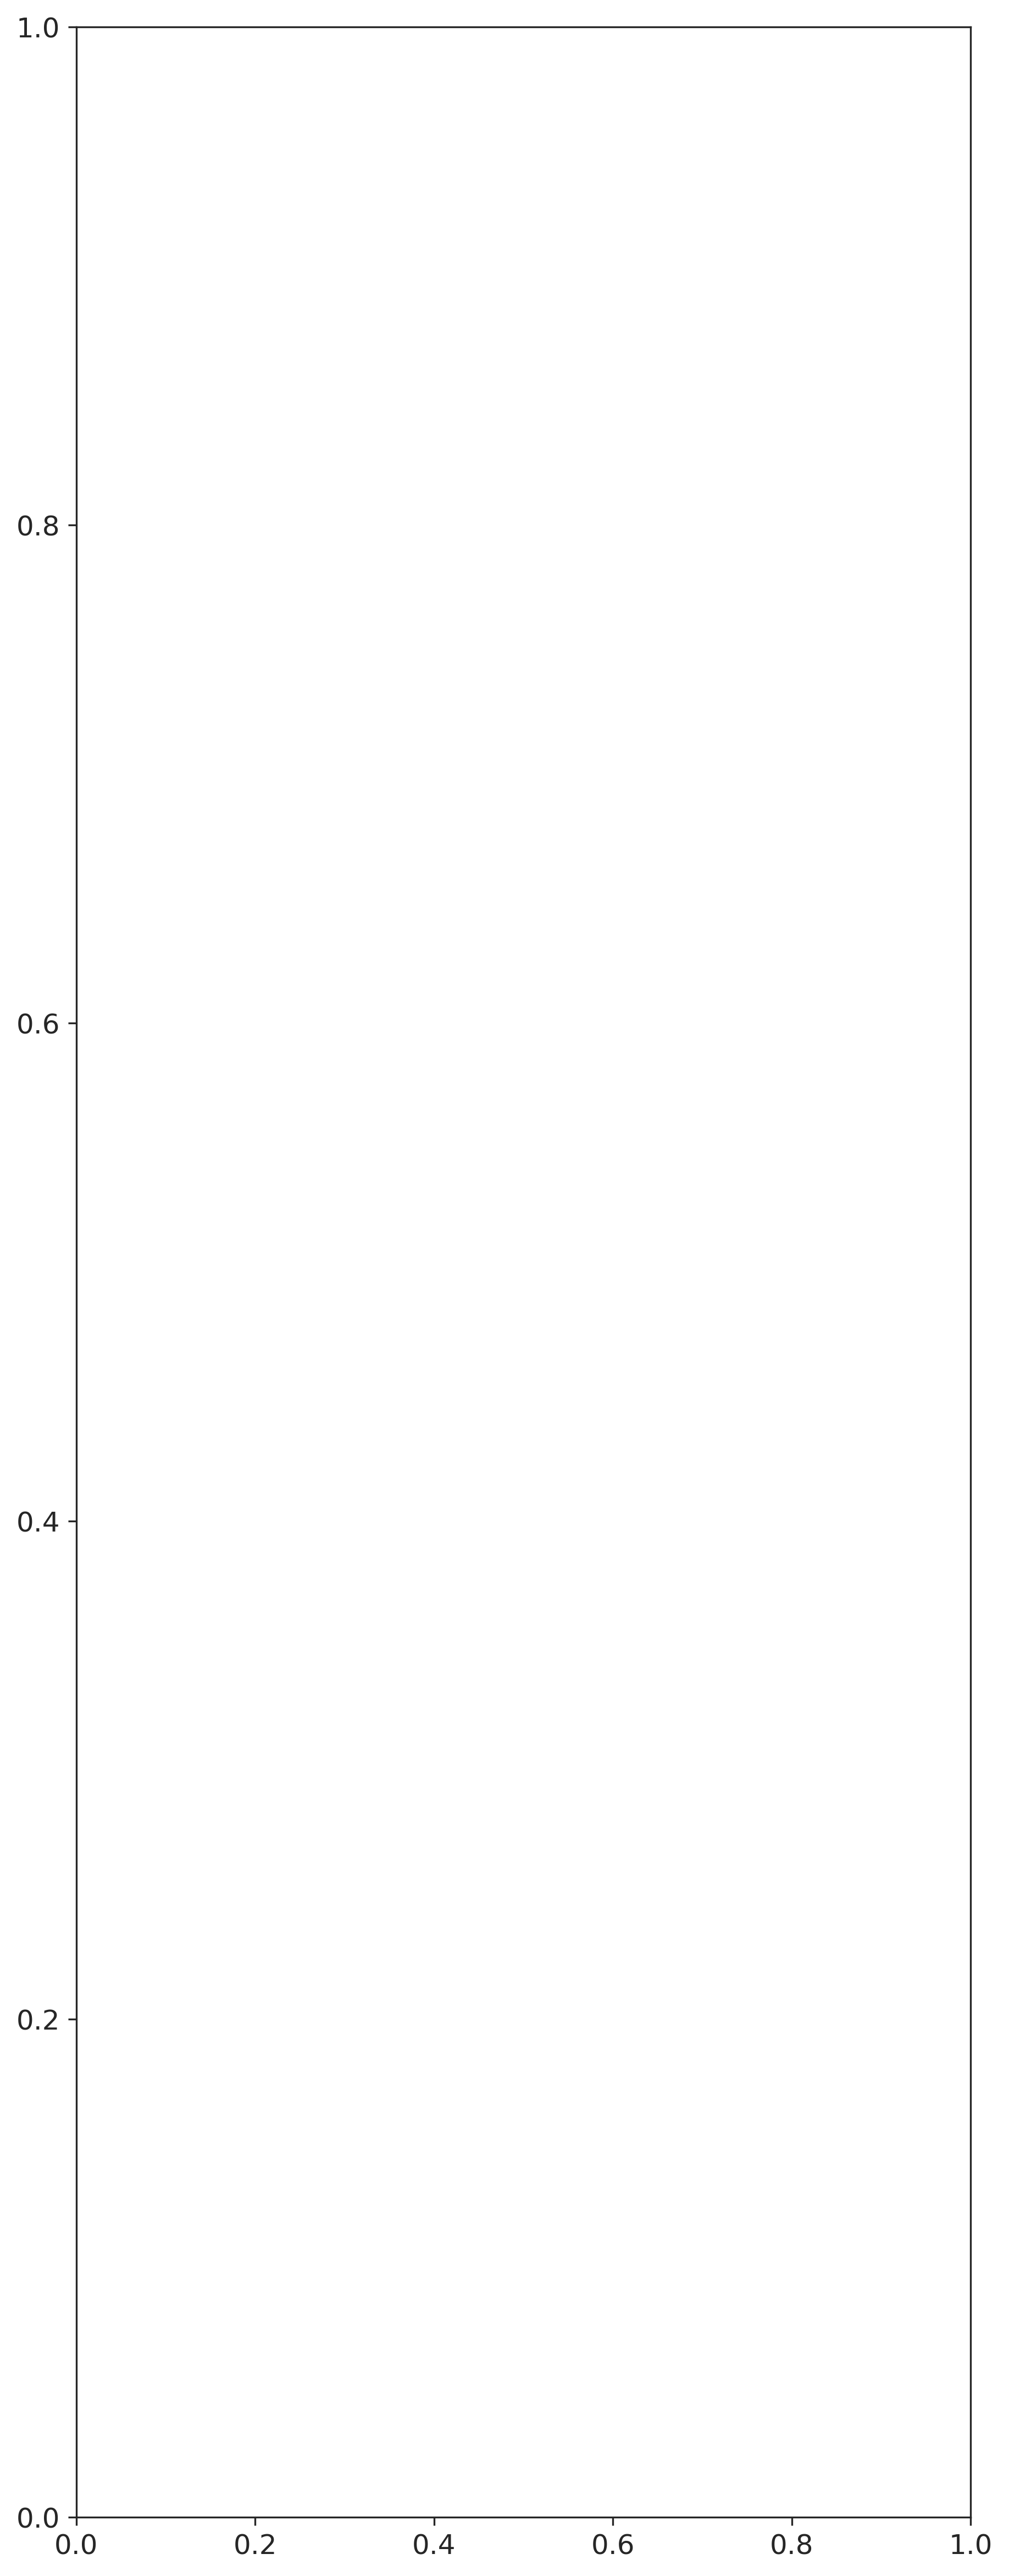

In [187]:
ut.findActofSwitchingCells(ab_sjoutdf=ab_tx, threshold=0.9, changeodb_H=changeodbH, plot = True )

In [180]:
_df = ab_tx[~ab_tx.exon_start.str.contains("IGHD")]

In [182]:
_df = _df[_df.exon_start.str.contains('exon1')]

In [184]:
_x = _df.groupby('cell').max() / _df.groupby('cell').sum()

In [186]:
_x.unique_mapping

cell
AgSeqPooled_A11               1.000000
AgSeqPooled_A12               1.000000
AgSeqPooled_A7                1.000000
AgSeqPooled_A9                0.549815
AgSeqPooled_B10               1.000000
                                ...   
PASL_5_PA_15_plate_2mod_H2    1.000000
PASL_5_PA_15_plate_2mod_H5    0.738095
PASL_5_PA_15_plate_2mod_H6    0.556818
PASL_5_PA_15_plate_2mod_H7    0.963636
PASL_5_PA_15_plate_2mod_H8    0.939394
Name: unique_mapping, Length: 2702, dtype: float64

In [192]:
act_cells = _x[_x.unique_mapping < 0.7].index

In [193]:
act_cells

Index(['AgSeqPooled_A9', 'AgSeqPooled_F8', 'AgSeqPooled_G1', 'AgSeqPooled_I10', 'AgSeqPooled_I4', 'AgSeqPooled_J3', 'AgSeqPooled_O1', 'AgSeqPooled_O11', 'AgSeqPooled_P6', 'B107906_A2',
       ...
       'PASL_5_PA_12_plate_4_E5', 'PASL_5_PA_12_plate_4_F1', 'PASL_5_PA_15_plate_2mod_B8', 'PASL_5_PA_15_plate_2mod_D7', 'PASL_5_PA_15_plate_2mod_E9', 'PASL_5_PA_15_plate_2mod_F10', 'PASL_5_PA_15_plate_2mod_F4', 'PASL_5_PA_15_plate_2mod_G8', 'PASL_5_PA_15_plate_2mod_G9', 'PASL_5_PA_15_plate_2mod_H6'], dtype='object', name='cell', length=315)

In [194]:
_act_cells_df = _df[_df.cell.isin(act_cells)]

In [195]:
_act_cells_df

,level_0,index,chrom,start,end,strand,intron_motif,annotated,unique_mapping,multi_mapping,max_overhang,cell,SAMPLE,J_exon,exon_start,exon_simple
326,2859,62901,14,105601728,105863813,2,2,1,156,2831,42,PASL_2_PA_11_plate_1_G10,Donor_11,IGHJ5,IGHE_exon1_5prime,IGHE
327,2860,62902,14,105601728,105864214,2,2,1,161,2863,41,PASL_2_PA_11_plate_1_G10,Donor_11,IGHJ4,IGHE_exon1_5prime,IGHE
328,2861,62903,14,105601728,105865406,2,2,1,4,303,41,PASL_2_PA_11_plate_1_G10,Donor_11,IGHJ1,IGHE_exon1_5prime,IGHE
1043,5705,139182,14,105743071,105863813,2,2,1,10,17,51,PASL_2_PA_11_plate_1_B5,Donor_11,IGHJ5,IGHG1_exon1_5prime,IGHG1
1044,5706,139183,14,105743071,105864214,2,2,1,10,11,47,PASL_2_PA_11_plate_1_B5,Donor_11,IGHJ4,IGHG1_exon1_5prime,IGHG1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236055,1779299,3597412,14,105644790,105863813,2,2,1,333,3660,43,B107906_E6,SS2,IGHJ5,IGHG2_exon1_5prime,IGHG2
236056,1779300,3597413,14,105644790,105864214,2,2,1,1729,5894,47,B107906_E6,SS2,IGHJ4,IGHG2_exon1_5prime,IGHG2
236057,1779301,3597414,14,105644790,105865198,2,2,1,5830,4417,49,B107906_E6,SS2,IGHJ2,IGHG2_exon1_5prime,IGHG2
236058,1779302,3597415,14,105644790,105865406,2,2,1,1043,2305,40,B107906_E6,SS2,IGHJ1,IGHG2_exon1_5prime,IGHG2


In [197]:
_act_cells_df.groupby(['cell','exon_start']).count()

,,level_0,index,chrom,start,end,strand,intron_motif,annotated,unique_mapping,multi_mapping,max_overhang,SAMPLE,J_exon,exon_simple
cell,exon_start,,,,,,,,,,,,,,
AgSeqPooled_A9,IGHA1_exon1_5prime,3,3,3,3,3,3,3,3,3,3,3,3,3,3
AgSeqPooled_F8,IGHM_exon1_5prime,3,3,3,3,3,3,3,3,3,3,3,3,3,3
AgSeqPooled_G1,IGHM_exon1_5prime,2,2,2,2,2,2,2,2,2,2,2,2,2,2
AgSeqPooled_I10,IGHM_exon1_5prime,2,2,2,2,2,2,2,2,2,2,2,2,2,2
AgSeqPooled_I4,IGHM_exon1_5prime,2,2,2,2,2,2,2,2,2,2,2,2,2,2
AgSeqPooled_J3,IGHM_exon1_5prime,2,2,2,2,2,2,2,2,2,2,2,2,2,2
AgSeqPooled_O1,IGHM_exon1_5prime,2,2,2,2,2,2,2,2,2,2,2,2,2,2
AgSeqPooled_O11,IGHM_exon1_5prime,3,3,3,3,3,3,3,3,3,3,3,3,3,3
AgSeqPooled_P6,IGHM_exon1_5prime,3,3,3,3,3,3,3,3,3,3,3,3,3,3


In [200]:
t = _act_cells_df.groupby('cell').J_exon.max()

In [206]:
my_dict = dict(zip(t.index, t.values))

In [208]:
my_dict

{'AgSeqPooled_A9': 'IGHJ5',
 'AgSeqPooled_F8': 'IGHJ6',
 'AgSeqPooled_G1': 'IGHJ5',
 'AgSeqPooled_I10': 'IGHJ5',
 'AgSeqPooled_I4': 'IGHJ6',
 'AgSeqPooled_J3': 'IGHJ5',
 'AgSeqPooled_O1': 'IGHJ6',
 'AgSeqPooled_O11': 'IGHJ6',
 'AgSeqPooled_P6': 'IGHJ5',
 'B107906_A2': 'IGHJ6',
 'B107906_C19': 'IGHJ6',
 'B107906_C21': 'IGHJ6',
 'B107906_C6': 'IGHJ6',
 'B107906_E6': 'IGHJ5',
 'B107906_I17': 'IGHJ6',
 'B107906_I6': 'IGHJ3',
 'B107906_M19': 'IGHJ6',
 'B107914_C3': 'IGHJ6',
 'B107914_E6': 'IGHJ4',
 'B107914_F20': 'IGHJ6',
 'B107914_H13': 'IGHJ5',
 'B107914_H4': 'IGHJ6',
 'B107914_I1': 'IGHJ6',
 'B107914_I3': 'IGHJ6',
 'B107914_N21': 'IGHJ6',
 'B107914_O10': 'IGHJ6',
 'B107914_O6': 'IGHJ6',
 'B107914_P10': 'IGHJ6',
 'B107914_P9': 'IGHJ6',
 'CTY_A12': 'IGHJ6',
 'CTY_B11': 'IGHJ6',
 'CTY_B4': 'IGHJ5',
 'CTY_B7': 'IGHJ5',
 'CTY_C18': 'IGHJ5',
 'CTY_D14': 'IGHJ4',
 'CTY_E10': 'IGHJ6',
 'CTY_E17': 'IGHJ6',
 'CTY_E9': 'IGHJ6',
 'CTY_F16': 'IGHJ6',
 'CTY_F17': 'IGHJ5',
 'CTY_F7': 'IGHJ6',
 'CTY_G13

In [210]:
_act_cells_df['Max_J'] = _act_cells_df['cell']

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [215]:
_act_cells_df['Max_J'] = _act_cells_df['Max_J'].map(my_dict)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [221]:
_df = _act_cells_df.groupby(['cell','Max_J', 'exon_simple']).count().unstack()

In [225]:
_df = _df.reset_index()

In [232]:
pd.DataFrame(_df.values)

KeyError: "None of ['0'] are in the columns"

In [228]:
_df.drop_duplicates(subset='cell')

KeyError: Index(['cell'], dtype='object')